LOADING NECCESSARY LIBRARIES

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
df = pd.read_csv("SPY_2000_2022.csv")
df.head()

,Date,Close,High,Low,Open,Volume,Adj Close
0,03/01/2000,91.367500,93.134384,90.385898,93.134384,8164300,91.367500
1,04/01/2000,87.794525,90.503748,87.725813,90.170003,8089800,87.794525
2,05/01/2000,87.951553,88.913523,86.223934,87.912289,12177900,87.951553
3,06/01/2000,86.538040,88.893885,86.538040,87.715963,6227200,86.538040
4,07/01/2000,91.563873,91.563873,87.990841,88.147897,8066500,91.563873


Split data into training and test sets

In [15]:
# Predictor (must be 2D)
X = df[['High',"Low","Open","Volume"]]

# Target / Response 
y = df['Adj Close']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = False)

Fit the model

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Extract slope and intercept
slope = model.coef_
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: [ 8.09337281e-01  8.00855110e-01 -6.09656651e-01  1.47180173e-11]
Intercept: -0.012968817013259581


The estimated regression model is given by: 

Scatterplot and abline between X and y

In [18]:
y_pred = model.predict(X_test)

data = {"actual": y_test, "predicted": y_pred}

pred_df = pd.DataFrame(data)
pred_df

,actual,predicted
4428,215.445084,215.174705
4429,212.404037,213.010764
4430,212.717697,213.094275
4431,214.826447,214.919773
4432,214.800293,214.754863
...,...,...
5531,450.219940,449.511504
5532,449.852051,450.461151
5533,450.427490,450.590196
5534,449.182221,450.190873


In [20]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (4428, 4)
y_train: (4428,)


Scatterplot and abline between X and y

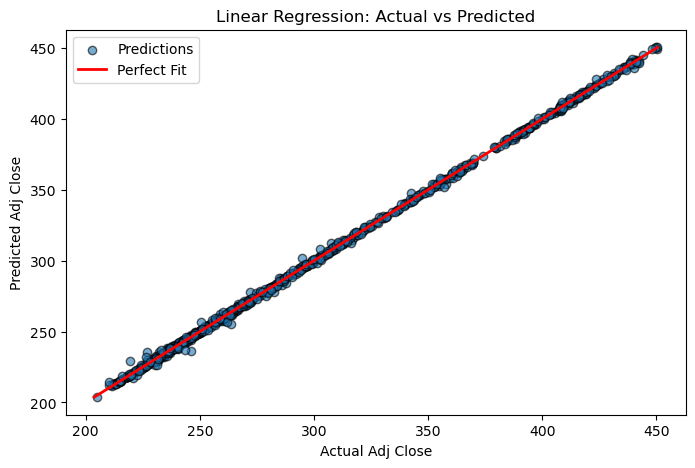

In [23]:
plt.figure(figsize=(8,5))

# Use test set predictions (already computed above as y_pred)
# Plotting Actual vs Predicted instead of X_train vs y_train,
# since X_train has 4 features (High, Low, Open, Volume) and
# can't be scattered directly against a single y value.
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", label="Predictions")

# Perfect-fit reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red",
         linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Adj Close")
plt.ylabel("Predicted Adj Close")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()

plt.show()


In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 1.6843
RMSE : 1.2978
R²   : 0.9996


In [25]:
y_pred_train = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")

MSE  : 0.1951
RMSE : 0.4417
R²   : 0.9999


In [27]:
dta = {"Train": {"MSE": 0.1951, "RMSE": 0.4417, "R_squared": 0.9999}, 
       "Test": {"MSE": 1.6843, "RMSE": 1.2978, "R_squared": 0.9999}}
final_df = pd.DataFrame(dta)
final_df

,Train,Test
MSE,0.1951,1.6843
RMSE,0.4417,1.2978
R_squared,0.9999,0.9999
